Fitted p = 0.990000
Estimated error rate r ≈ 5.000000e-03


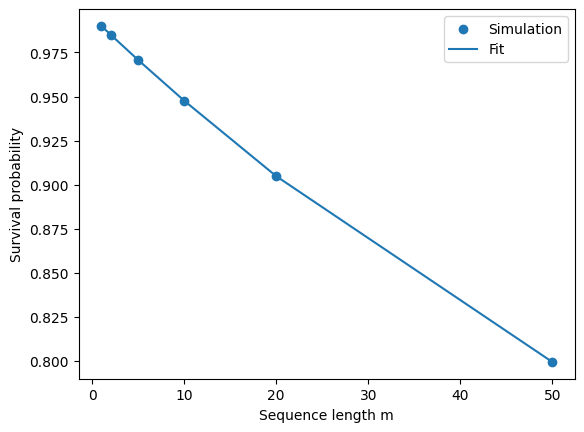

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ----------------------------
# 1. Define basic single-qubit gates
# ----------------------------
I = np.array([[1, 0], [0, 1]], dtype=complex)
X = np.array([[0, 1], [1, 0]], dtype=complex)
Y = np.array([[0, -1j], [1j, 0]], dtype=complex)
Z = np.array([[1, 0], [0, -1]], dtype=complex)

# Clifford-like small set (not full Clifford group, but enough for demo)
gates = [I, X, Y, Z]

# ----------------------------
# 2. Noise model: depolarizing channel
# ----------------------------
def depolarizing(rho, p):
    d = 2
    return (1 - p) * rho + p * np.eye(d) / d

# ----------------------------
# 3. Apply a gate with noise
# ----------------------------
def apply_gate(rho, U, noise_strength):
    rho = U @ rho @ U.conj().T
    rho = depolarizing(rho, noise_strength)
    return rho

# ----------------------------
# 4. RB sequence simulation
# ----------------------------
def run_rb_sequence(m, noise_strength):
    # initial state |0><0|
    rho = np.array([[1, 0], [0, 0]], dtype=complex)

    sequence = []

    # random gates
    for _ in range(m):
        U = gates[np.random.randint(len(gates))]
        sequence.append(U)
        rho = apply_gate(rho, U, noise_strength)

    # compute inverse (ideal)
    U_total = np.eye(2, dtype=complex)
    for U in sequence:
        U_total = U @ U_total
    U_inv = np.linalg.inv(U_total)

    # apply inverse (with noise too)
    rho = apply_gate(rho, U_inv, noise_strength)

    # measure probability of |0>
    prob_0 = np.real(rho[0, 0])
    return prob_0

# ----------------------------
# 5. Run RB experiment
# ----------------------------
def run_rb(noise_strength, m_values, n_sequences=50):
    results = []

    for m in m_values:
        probs = [run_rb_sequence(m, noise_strength) for _ in range(n_sequences)]
        results.append(np.mean(probs))

    return np.array(results)

# ----------------------------
# 6. Fit exponential decay
# ----------------------------
def rb_decay(m, A, p, B):
    return A * (p ** m) + B

# ----------------------------
# 7. Main simulation
# ----------------------------
noise_strength = 0.01  # try ~0.001 to mimic better hardware
m_values = np.array([1, 2, 5, 10, 20, 50])

data = run_rb(noise_strength, m_values)

# fit
params, _ = curve_fit(rb_decay, m_values, data, p0=[0.5, 0.99, 0.5])
A_fit, p_fit, B_fit = params

# compute error rate
r = (1 - p_fit) / 2

print(f"Fitted p = {p_fit:.6f}")
print(f"Estimated error rate r ≈ {r:.6e}")

# ----------------------------
# 8. Plot
# ----------------------------
plt.scatter(m_values, data, label="Simulation")
plt.plot(m_values, rb_decay(m_values, *params), label="Fit")
plt.xlabel("Sequence length m")
plt.ylabel("Survival probability")
plt.legend()
plt.show()